<a href="https://colab.research.google.com/github/Royromero/audiofiles_preply_transcript/blob/main/audio_transcript_preply.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:

pip install openai.whisper

In [4]:
"""

Main objetive is to gathering the audio files from the lesson recordings and transcribe them to text, then clean the text by removing accents and stopwords, and finally visualize the most common words in a bar plot.
After that, we will send the text to ChatGPT to summarize the text and generate a study guide for the lesson.

"""
import whisper
import os
import unicodedata
from nltk.corpus import stopwords
import nltk
from collections import Counter
import matplotlib.pyplot as plt
import re
import numpy as np
import math


In [5]:
"""load the model from OpenAI to make the transcription of the audio file"""
model = whisper.load_model("tiny")

100%|█████████████████████████████████████| 72.1M/72.1M [00:01<00:00, 65.3MiB/s]


In [6]:
def gathering_audio_files(dir_path):
    """
    Gather all audio files from the specified folder and return a list of their paths.
    """
    complete_text = []
    num_files = len(os.listdir(dir_path))
    for file in range(num_files):
         file= os.listdir(dir_path)[file]
         file_dir = os.path.join(dir_path, file)
         result = model.transcribe(file_dir)
         concatenated_text = result["text"]
         complete_text.append(concatenated_text)
         #print(f"File {file+1}/{num_files} processed: {file} characters: {len(concatenated_text)}")
    complete_text_str = "".join(complete_text)
    return complete_text_str

In [17]:
#Cargar google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
base_path = "/content/drive/MyDrive/preply_project"
#folders = os.listdir(base_path)
folders = ['lesson_recordings (1)', 'lesson_recordings (2)','lesson_recordings (3)','lesson_recordings (4)','lesson_recordings (5)']
data = {}
for folder in folders:
    folder_path = os.path.join(base_path, folder)
    if os.path.isdir(folder_path):
        data[folder] = gathering_audio_files(folder_path)

In [45]:
"""We break down complete text in chunks"""

complete_text_str=data['lesson_recordings (3)']
# Example: Split text by sentences or line breaks
segments = complete_text_str.split('. ')
# Ensure you filter out empty strings
segments = [s.strip() for s in segments if s.strip()]

In [46]:
"""We tranform the text chunck into numerical chunks trough TF-IDF Term Frequency-Inverse Document Frequency"""
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert text segments into numerical vectors
vectorizer = TfidfVectorizer(ngram_range=(1,1),stop_words='english')
X = vectorizer.fit_transform(segments)

In [47]:

"""Now we apply k-mean algorithm to clusterizing the chucks in two categories"""
from sklearn.cluster import KMeans

# Define the model for 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X)

In [48]:
import pandas as pd

# Create a clean DataFrame to view the results
df = pd.DataFrame({
    'Speaker_Cluster': labels,
    'Text_Segment': segments
})

# Preview the results
print(df.head(50))

    Speaker_Cluster                                       Text_Segment
0                 0  for sewing my goal and that in this case was t...
1                 0  In this case I was able to build certain skill...
2                 0  As I've resolved I got nowadays I could unders...
3                 0               Sounds quite similar to mine as well
4                 0  When I went through certain situations in my l...
5                 0  Discipline is the exact mindset that I would n...
6                 0                                     I can see that
7                 0                                   That's very good
8                 0  Now let's try another topic shall we? I'll pic...
9                 0                                       I'll ask you
10                0                 This is quite an interesting topic
11                0  We can you don't need to think too hard about ...
12                0                     This is just discussing it now
13    

In [49]:
df['Speaker_Cluster'][0]

np.int32(0)

In [51]:
# Ver 10 ejemplos asignados al Cluster 0
print("--- MUESTRA DEL CLUSTER 0 ---")
print(df[df['Speaker_Cluster'] == 0]['Text_Segment'].sample(min(10, len(df))).values)

print("\n--- MUESTRA DEL CLUSTER 1 ---")
# Ver 10 ejemplos asignados al Cluster 1
print(df[df['Speaker_Cluster'] == 1]['Text_Segment'].sample(min(10, len(df))).values)

--- MUESTRA DEL CLUSTER 0 ---
['the motivation, you can..'
 "because the tricky thing about certain songs is they don't have any comments"
 'Just the conversation between you and me'
 "No, we're, this is just a little conversation between the both of us"
 'So you just vocalize that, figure out where you stop, where you pop'
 'Good' 'Did we finish the workbook itself? Yes, we did'
 'Will your mouth still remember the taste of my love? And will your eyes still smile from your cheeks? But darling, I will be loving you till we are 70'
 'When you are, when you are focusing on something'
 "All right, so I'm going to show you a little bit of what I mean"]

--- MUESTRA DEL CLUSTER 1 ---
['Okay' "That's okay" 'Okay' 'Okay' 'Okay' 'Okay' 'Okay' 'Okay' 'Okay'
 'Okay']


In [52]:
# Contar la distribución
print(df['Speaker_Cluster'].value_counts())

Speaker_Cluster
0    428
1     56
Name: count, dtype: int64


In [53]:
# Obtener las palabras del vectorizador
terms = vectorizer.get_feature_names_out()

# Ordenar los centroides de los clusters
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(2):
    print(f"\n📢 Palabras clave más importantes del Cluster {i}:")
    top_words = [terms[ind] for ind in order_centroids[i, :50]] # Top 10 palabras
    print(", ".join(top_words))


📢 Palabras clave más importantes del Cluster 0:
right, good, like, little, bit, want, just, let, ll, words, think, don, know, going, really, try, use, example, maybe, new, need, motivation, things, time, thing, okay, discipline, speaking, kind, talk, talking, yes, beginner, actually, ve, um, different, certain, experience, topic, yeah, did, workbook, moment, using, case, conversation, important, learn, song

📢 Palabras clave más importantes del Cluster 1:
okay, right, alright, tell, focused, focus, fluent, fluency, fitness, fit, finished, focusing, fine, finance, filipino, figure, fields, field, fickness, feet, feel, finish, good, gonna, going, goals, goal, giving, given, getting, general, forget, gain, future, frameworks, framework, foundations, forward, forth, form, feedback, gave, expand, exercises, exercise, executed, example, exactly, exact, eventually


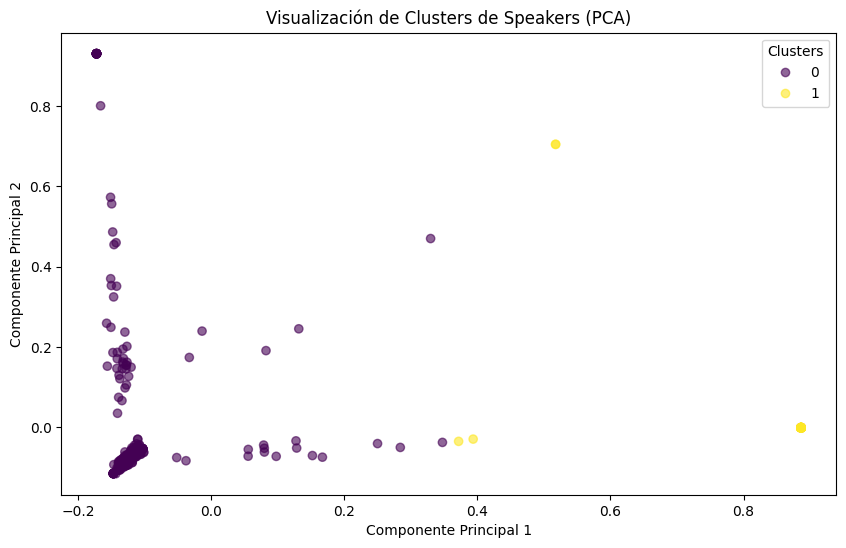

In [54]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reducir las dimensiones de la matriz TF-IDF a 2 componentes
pca = PCA(n_components=2, random_state=42)
X_dense = X.todense()
coords = pca.fit_transform(np.asarray(X_dense))

# Graficar los puntos coloreados por su cluster
plt.figure(figsize=(10, 6))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=labels, cmap='viridis', alpha=0.6)

plt.title('Visualización de Clusters de Speakers (PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

terms = vectorizer.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(2):
    print(f"\n📢 Palabras clave más importantes del Cluster {i}:")
    top_words = [terms[ind] for ind in order_centroids[i, :10]]
    print(", ".join(top_words))

In [56]:
terms = vectorizer.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

cluster_names = {0: 'Student Cluster (0)', 1: 'Teacher Cluster (1)'}

for i in range(2):
    print(f"\n📢 Palabras clave más importantes del {cluster_names[i]}:")
    top_words = [terms[ind] for ind in order_centroids[i, :10]]
    print(", ".join(top_words))


📢 Palabras clave más importantes del Student Cluster (0):
right, good, like, little, bit, want, just, let, ll, words

📢 Palabras clave más importantes del Teacher Cluster (1):
okay, right, alright, tell, focused, focus, fluent, fluency, fitness, fit
